# Analisi PRE_CONS — Lettura da file Excel (22 soggetti)

Questo notebook:
1. Legge le **diagnosi** dal file `000_STATO_AVANZAMENTO_ANALISI.xlsx` (colonna `diagnosi`, foglio `reclutamento`)
2. Apre ciascuno dei 22 file `NN_risposte.xlsx` nella sottocartella `risposte/`
3. Costruisce un **DataFrame risposte** (righe = soggetti, colonne = domande + diagnosi)
4. Costruisce un **DataFrame conteggi** (caratteri, parole, espressioni salienti per domanda + totale)


## 1. Import delle librerie

In [32]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from openpyxl import load_workbook


## 2. Configurazione percorsi

In [33]:
# -----------------------------------------------------------------------
# Modifica questi percorsi se necessario
# -----------------------------------------------------------------------

# Cartella contenente il notebook e la sottocartella 'risposte/'
BASE_DIR = Path(".")  # cartella corrente (dove si trova il notebook)

# File Excel con le diagnosi
EXCEL_DIAGNOSI = BASE_DIR / "000_STATO_AVANZAMENTO_ANALISI.xlsx"

# Sottocartella con i 22 file risposte
RISPOSTE_DIR = BASE_DIR / "risposte"

# Numero di soggetti attesi
N_SOGGETTI = 22

# Foglio da leggere in ogni file risposte
SHEET_PRE = "PRE_CONS"

print(f"BASE_DIR     : {BASE_DIR.resolve()}")
print(f"RISPOSTE_DIR : {RISPOSTE_DIR.resolve()}")
print(f"EXCEL_DIAGNOSI: {EXCEL_DIAGNOSI.resolve()}")
print(f"La cartella risposte/ esiste: {RISPOSTE_DIR.exists()}")


BASE_DIR     : C:\Users\giugg\OneDrive\Desktop\brondino\DIAGNOSI
RISPOSTE_DIR : C:\Users\giugg\OneDrive\Desktop\brondino\DIAGNOSI\risposte
EXCEL_DIAGNOSI: C:\Users\giugg\OneDrive\Desktop\brondino\DIAGNOSI\000_STATO_AVANZAMENTO_ANALISI.xlsx
La cartella risposte/ esiste: True


## 3. Funzioni di supporto

In [34]:
def conta_parole(testo: str) -> int:
    """Conta le parole usando come separatore qualsiasi carattere non-lettera."""
    return len(re.findall(r"[a-zA-ZÀ-ÿ]+", testo))


def conta_caratteri(testo: str) -> int:
    """Conta i caratteri spazi inclusi."""
    return len(testo)


def normalizza_diagnosi(raw) -> list:
    """
    Converte il valore grezzo della colonna 'diagnosi' in una lista di etichette
    standard, gestendo diagnosi singole e multiple nella stessa cella.

    La cella può contenere una o più diagnosi separate da virgola, punto e virgola
    o slash (es. "autismo, ADHD" oppure "DSA; plusdotazione").
    Il confronto è case-insensitive: "Autismo", "AUTISMO" e "autismo" sono equivalenti.

    Mappatura applicata a ciascun elemento dopo lo split:
      - contiene 'autismo'                    → 'Autismo'
      - contiene 'adhd'                       → 'ADHD'
      - contiene 'plusdotazione'              → 'Plusdotazione'
      - contiene 'apc'                        → 'APC'
      - contiene 'dsa'                        → 'DSA'
      - None / stringa vuota (cella intera)   → ['diagnosi in corso']
      - qualsiasi altro valore non riconosciuto → valore originale strip()

    Restituisce:
      list[str] — lista con almeno un elemento
                  es. ['Autismo', 'ADHD'] oppure ['diagnosi in corso']
    """
    # Se la cella è vuota o None restituiamo subito il placeholder
    if raw is None or str(raw).strip() == "":
        return ["diagnosi in corso"]

    # Splittiamo su virgola, punto e virgola o slash per gestire diagnosi multiple
    # re.split con pattern '[,;/]+' separa anche sequenze consecutive di separatori
    parti = re.split(r"[,;/]+", str(raw).strip())

    risultati = []  # lista delle etichette normalizzate per questa cella

    for parte in parti:
        # Rimuoviamo spazi iniziali/finali da ogni frammento
        parte = parte.strip()

        # Saltiamo frammenti vuoti prodotti da separatori doppi o finali
        if not parte:
            continue

        # Convertiamo in minuscolo solo per il confronto (non modifica l'output)
        s = parte.lower()

        # Confronto case-insensitive → etichetta canonica
        if "autismo" in s:
            etichetta = "Autismo"
        elif "adhd" in s:
            etichetta = "ADHD"
        elif "plusdotazione" in s:
            etichetta = "Plusdotazione"
        elif "apc" in s:
            etichetta = "APC"
        elif "dsa" in s:
            etichetta = "DSA"
        else:
            # Valore non riconosciuto: manteniamo il testo originale (solo strip)
            etichetta = parte

        # Aggiungiamo solo se non è già presente (evita duplicati da dati sporchi)
        if etichetta not in risultati:
            risultati.append(etichetta)

    # Se dopo lo split non abbiamo ricavato nulla, usiamo il placeholder
    return risultati if risultati else ["diagnosi in corso"]


def leggi_risposte_e_espressioni(ws, soggetto_id=""):
    """
    Legge risposte ed espressioni salienti da un foglio PRE_CONS.

    Restituisce:
      risposte            : dict {Q1: str, …}
      espressioni_salienti: dict {Q1: int|None, …}
                            → None se la suddivisione in esp. salienti è assente
                              o non annotata per quella domanda
      avvisi              : list[str] — problemi rilevati

    Controllo espressioni salienti (colonna Q+1, riga 3 subheader, riga 4+ annotazioni):
      1. Subheader assente in riga 3  → esp = None  + avviso
      2. Subheader presente ma 0 righe annotate → esp = None + avviso
      3. Annotazioni presenti          → esp = conteggio
    """
    avvisi = []
    rows = list(ws.iter_rows(values_only=True))

    if len(rows) < 2:
        avvisi.append(f"{soggetto_id}: foglio con meno di 2 righe")
        return {}, {}, avvisi

    header_row  = rows[0]
    answer_row  = rows[1]
    subhead_row = rows[2] if len(rows) > 2 else ()

    # Trova colonne domande (Q*) nella riga 1
    q_cols = {}
    for i, val in enumerate(header_row):
        if val and str(val).startswith("Q"):
            q_label = str(val).split(".")[0].strip()
            q_cols[q_label] = i

    if not q_cols:
        avvisi.append(f"{soggetto_id}: nessuna colonna Q* trovata in riga 1")
        return {}, {}, avvisi

    # Risposte dalla riga 2
    risposte = {}
    for q, col in q_cols.items():
        val = answer_row[col] if col < len(answer_row) else None
        if val:
            text = str(val).strip()
            text = re.sub(r'^[\d]+\.\s*"?', '', text)
            text = text.strip('"').strip().replace('""', '"')
            risposte[q] = text
        else:
            risposte[q] = ""

    # Verifica subheader riga 3 per ogni colonna Q+1
    KEYWORDS_SUBHEAD = {"espressioni", "esperienza", "salienti"}
    subhead_ok = {}
    for q, col in q_cols.items():
        esp_col = col + 1
        cell_val = ""
        if subhead_row and esp_col < len(subhead_row) and subhead_row[esp_col] is not None:
            cell_val = str(subhead_row[esp_col]).strip().lower()
        found = any(kw in cell_val for kw in KEYWORDS_SUBHEAD)
        subhead_ok[q] = found
        if not found:
            avvisi.append(
                f"{soggetto_id} {q}: subheader 'espressioni salienti' assente "
                f"(riga 3, col {esp_col} = '{cell_val or 'vuoto'}')"
            )

    # Conta annotazioni dalla riga 4 in poi
    raw_count = {q: 0 for q in q_cols}
    for row in rows[3:]:
        for q, col in q_cols.items():
            esp_col = col + 1
            if esp_col < len(row) and row[esp_col] is not None:
                raw_count[q] += 1

    # Assegna conteggio o None
    espressioni_salienti = {}
    for q in q_cols:
        if not subhead_ok[q]:
            espressioni_salienti[q] = None  # suddivisione assente
        elif raw_count[q] == 0:
            avvisi.append(
                f"{soggetto_id} {q}: subheader presente ma "
                f"nessuna espressione saliente annotata"
            )
            espressioni_salienti[q] = None  # annotazione mancante
        else:
            espressioni_salienti[q] = raw_count[q]

    return risposte, espressioni_salienti, avvisi


## 4. Lettura diagnosi dal file Excel

In [35]:
# -----------------------------------------------------------------------
# Sezione 4 — Lettura diagnosi dal file Excel
#
# Struttura attesa del foglio 'reclutamento':
#   col 0 → codice soggetto (es. 'RD_01', 'RD_22')
#   col 2 → diagnosi grezza (es. 'Autismo, ADHD' oppure 'DSA')
#
# Risultato: diagnosi_map = {'01': ['Autismo', 'ADHD'], '02': ['DSA'], …}
#            Ogni soggetto è associato a una LISTA di etichette standard,
#            per gestire correttamente le diagnosi multiple.
# -----------------------------------------------------------------------

# Apriamo il file Excel in modalità sola lettura per risparmiare memoria
wb_diag = load_workbook(EXCEL_DIAGNOSI, read_only=True)

# Selezioniamo il foglio 'reclutamento' che contiene i dati di reclutamento
ws_diag = wb_diag["reclutamento"]

# Dizionario principale: chiave = numero soggetto con zero padding (es. '01'),
# valore = lista di diagnosi normalizzate (es. ['Autismo', 'ADHD'])
diagnosi_map = {}

# Iteriamo sulle righe del foglio, saltando la prima (intestazione colonne)
for row in ws_diag.iter_rows(min_row=2, values_only=True):

    # Col 0: codice soggetto nel formato 'RD_NN' (es. 'RD_01')
    codice = row[0]

    # Saltiamo le righe senza codice (righe vuote o di separazione)
    if codice is None:
        continue

    # Estraiamo il numero progressivo finale dal codice (es. 'RD_01' → '1')
    match = re.search(r"(\d+)$", str(codice))

    # Se il codice non contiene cifre finali lo saltiamo (formato inatteso)
    if not match:
        continue

    # Normalizziamo a due cifre con zero padding: '1' → '01', '9' → '09'
    num = match.group(1).zfill(2)

    # Col 2 (indice 2): cella con la/le diagnosi grezze del soggetto
    raw_diagnosi = row[2]

    # normalizza_diagnosi restituisce sempre una lista (anche se vuota → placeholder)
    # Gestiamo diagnosi multiple nella stessa cella (es. 'Autismo, ADHD')
    lista_diagnosi = normalizza_diagnosi(raw_diagnosi)

    # Se il soggetto non era ancora nel dizionario, creiamo la voce
    if num not in diagnosi_map:
        diagnosi_map[num] = []

    # Aggiungiamo le nuove diagnosi evitando duplicati
    # (utile se il soggetto comparisse su più righe nel foglio)
    for diagnosi in lista_diagnosi:
        if diagnosi not in diagnosi_map[num]:
            diagnosi_map[num].append(diagnosi)

# -----------------------------------------------------------------------
# Riepilogo a console: quanti soggetti e quali diagnosi sono stati caricati
# -----------------------------------------------------------------------

# Stampiamo il totale di soggetti per cui abbiamo trovato una diagnosi
print(f"Diagnosi caricate per {len(diagnosi_map)} soggetti:")

# Iteriamo in ordine crescente per numero soggetto
for k, v in sorted(diagnosi_map.items()):
    # Uniamo le diagnosi con ' + ' per una visualizzazione compatta
    # es. Soggetto 01: Autismo + ADHD
    print(f"  Soggetto {k}: {' + '.join(v)}")


Diagnosi caricate per 26 soggetti:
  Soggetto 01: Autismo
  Soggetto 02: ADHD
  Soggetto 03: Plusdotazione + dislessia + UHR
  Soggetto 04: ADHD
  Soggetto 05: Autismo + ADHD
  Soggetto 06: Autismo
  Soggetto 07: nessuna
  Soggetto 08: nessuna (BAP)
  Soggetto 09: Autismo
  Soggetto 10: Autismo
  Soggetto 11: Autismo
  Soggetto 12: ADHD
  Soggetto 13: APC
  Soggetto 14: ADHD
  Soggetto 15: Autismo
  Soggetto 16: ADHD
  Soggetto 17: Autismo
  Soggetto 18: diagnosi in corso
  Soggetto 19: diagnosi in corso
  Soggetto 20: diagnosi in corso
  Soggetto 21: diagnosi in corso
  Soggetto 22: Autismo
  Soggetto 23: nessuna (BAP)
  Soggetto 24: nessuna
  Soggetto 25: diagnosi in corso
  Soggetto 26: diagnosi in corso


## 5. Lettura dei 22 file risposte

In [36]:
# -----------------------------------------------------------------------
# Sezione 5 — Lettura dei 22 file risposte
# -----------------------------------------------------------------------

records_risposte = []   # un record per soggetto → diventerà df_risposte
records_conteggi = []   # un record per soggetto → diventerà df_conteggi
log_files        = []   # stato di lettura di ogni file (OK / errore)
tutti_avvisi     = []   # raccoglie tutti gli avvisi sulle espressioni salienti

for n in range(1, N_SOGGETTI + 1):

    # Numero soggetto con zero padding: 1 → '01', 9 → '09'
    num_str = str(n).zfill(2)

    # Nome e percorso del file risposte atteso
    fname  = f"{num_str}_risposte.xlsx"
    fpath  = RISPOSTE_DIR / fname

    # ----------------------------------------------------------------
    # Recupero diagnosi da diagnosi_map e conversione a stringa
    #
    # diagnosi_map contiene liste (es. ['Autismo', 'ADHD']).
    # Convertiamo subito in stringa con ' + ' come separatore:
    #   ['Autismo', 'ADHD'] → 'Autismo + ADHD'
    #   ['DSA']             → 'DSA'
    # Questo garantisce che la colonna 'diagnosi' nei DataFrame sia
    # sempre un tipo hashable, compatibile con groupby e test statistici.
    # Il fallback è la stringa 'diagnosi in corso' se il soggetto
    # non è presente in diagnosi_map.
    # ----------------------------------------------------------------
    raw_diag = diagnosi_map.get(num_str, ["diagnosi in corso"])
    diagnosi = " + ".join(raw_diag) if isinstance(raw_diag, list) else str(raw_diag)

    soggetto_id = f"S{num_str}"

    # -- Verifica esistenza file --
    if not fpath.exists():
        log_files.append({"soggetto": soggetto_id, "file": fname,
                          "stato": "FILE NON TROVATO"})
        print(f"  ⚠️  {soggetto_id}: file non trovato → {fpath}")
        continue

    # -- Apertura workbook --
    try:
        wb_r = load_workbook(fpath, read_only=True)
    except Exception as e:
        log_files.append({"soggetto": soggetto_id, "file": fname,
                          "stato": f"ERRORE APERTURA: {e}"})
        print(f"  ❌ {soggetto_id}: errore apertura → {e}")
        continue

    # -- Verifica foglio PRE_CONS --
    if SHEET_PRE not in wb_r.sheetnames:
        log_files.append({"soggetto": soggetto_id, "file": fname,
                          "stato": f"FOGLIO '{SHEET_PRE}' ASSENTE"})
        print(f"  ⚠️  {soggetto_id}: foglio '{SHEET_PRE}' non trovato")
        continue

    ws_r = wb_r[SHEET_PRE]

    # -- Lettura risposte + controllo espressioni salienti --
    risposte, espressioni_salienti, avvisi = leggi_risposte_e_espressioni(
        ws_r, soggetto_id=soggetto_id
    )

    # Esponiamo eventuali avvisi a console
    if avvisi:
        tutti_avvisi.extend(avvisi)
        for av in avvisi:
            print(f"    ⚠️  {av}")

    # Contiamo domande con esp. salienti annotate vs mancanti
    n_esp_ok   = sum(1 for v in espressioni_salienti.values() if v is not None)
    n_esp_none = sum(1 for v in espressioni_salienti.values() if v is None)
    esp_stato  = "OK" if n_esp_none == 0 else f"ESP PARZIALI ({n_esp_ok}/{len(espressioni_salienti)})"

    log_files.append({"soggetto": soggetto_id, "file": fname,
                      "stato": "OK", "esp_salienti": esp_stato,
                      "domande_trovate": list(risposte.keys())})
    print(f"  ✅ {soggetto_id}: {len(risposte)} domande, diagnosi={diagnosi}, esp={esp_stato}")

    # -- Record df_risposte: soggetto | diagnosi (stringa) | Q1 … Q7 --
    rec_risp = {"soggetto": soggetto_id, "diagnosi": diagnosi}
    for q, testo in risposte.items():
        rec_risp[q] = testo
    records_risposte.append(rec_risp)

    # -- Record df_conteggi: soggetto | diagnosi (stringa) | conteggi per domanda + totali --
    rec_cnt    = {"soggetto": soggetto_id, "diagnosi": diagnosi}
    tot_char   = tot_words = tot_esp = 0
    esp_ha_nan = False

    for q, testo in risposte.items():
        nc = conta_caratteri(testo)      # numero di caratteri
        nw = conta_parole(testo)         # numero di parole
        ne = espressioni_salienti.get(q) # int se annotato, None se mancante

        rec_cnt[f"{q}_char"]   = nc
        rec_cnt[f"{q}_parole"] = nw
        rec_cnt[f"{q}_esp"]    = ne  # diventerà NaN nel DataFrame se None

        tot_char  += nc
        tot_words += nw
        if ne is not None:
            tot_esp += ne
        else:
            esp_ha_nan = True  # almeno una domanda senza annotazione

    # TOT_esp è NaN se anche una sola domanda non ha annotazioni
    rec_cnt["TOT_char"]   = tot_char
    rec_cnt["TOT_parole"] = tot_words
    rec_cnt["TOT_esp"]    = None if esp_ha_nan else tot_esp
    records_conteggi.append(rec_cnt)

# Riepilogo finale
print(f"\nFile OK: {sum(1 for l in log_files if l['stato']=='OK')}/{N_SOGGETTI}")
if tutti_avvisi:
    print(f"\n⚠️  Totale avvisi espressioni salienti: {len(tutti_avvisi)}")
    for av in tutti_avvisi:
        print(f"   - {av}")
else:
    print("✅  Nessun problema rilevato nelle espressioni salienti.")


  ✅ S01: 6 domande, diagnosi=Autismo, esp=OK
  ✅ S02: 6 domande, diagnosi=ADHD, esp=OK
  ✅ S03: 6 domande, diagnosi=Plusdotazione + dislessia + UHR, esp=OK
  ✅ S04: 6 domande, diagnosi=ADHD, esp=OK
  ✅ S05: 6 domande, diagnosi=Autismo + ADHD, esp=OK
  ✅ S06: 6 domande, diagnosi=Autismo, esp=OK
  ⚠️  S07: file non trovato → risposte\07_risposte.xlsx
  ⚠️  S08: file non trovato → risposte\08_risposte.xlsx
  ✅ S09: 6 domande, diagnosi=Autismo, esp=OK
  ✅ S10: 6 domande, diagnosi=Autismo, esp=OK
  ⚠️  S11: file non trovato → risposte\11_risposte.xlsx
  ✅ S12: 6 domande, diagnosi=ADHD, esp=OK
  ✅ S13: 6 domande, diagnosi=APC, esp=OK
  ✅ S14: 6 domande, diagnosi=ADHD, esp=OK
  ⚠️  S15: file non trovato → risposte\15_risposte.xlsx
  ✅ S16: 6 domande, diagnosi=ADHD, esp=OK
  ✅ S17: 6 domande, diagnosi=Autismo, esp=OK
  ⚠️  S18: file non trovato → risposte\18_risposte.xlsx
  ⚠️  S19: file non trovato → risposte\19_risposte.xlsx
  ⚠️  S20: file non trovato → risposte\20_risposte.xlsx
    ⚠️  S21

## 6. Costruzione dei DataFrame

In [37]:
# -----------------------------------------------------------------------
# DataFrame 1: RISPOSTE
# Righe = soggetti, Colonne = soggetto | diagnosi | Q1 | Q2 | … | Q7
# -----------------------------------------------------------------------
df_risposte = pd.DataFrame(records_risposte)

# Ordiniamo le colonne: soggetto, diagnosi, poi Q in ordine numerico
q_cols_risp = sorted([c for c in df_risposte.columns if c.startswith("Q")],
                     key=lambda x: int(re.sub(r'\D', '', x)))
df_risposte = df_risposte[["soggetto", "diagnosi"] + q_cols_risp]
df_risposte = df_risposte.set_index("soggetto")

print(f"df_risposte: {df_risposte.shape[0]} soggetti × {df_risposte.shape[1]} colonne")
df_risposte


df_risposte: 14 soggetti × 7 colonne


,diagnosi,Q1,Q2,Q3,Q5,Q6,Q7
soggetto,,,,,,,
S01,Autismo,Principalmente perché stavo davvero molto male...,Si. Per esempio psichiatri ed altri terapeuti ...,"Si, anche se non era il motivo principale per ...",La curiosità è facile da spiegare perché le ne...,"Non tanto sulla ricerca della diagnosi, ma su ...","Dipende dalla persona, con alcuni pessima, con..."
S02,ADHD,La fatica riscontrata a fare cose quotidiane p...,"Sicuramente a comprendermi meglio, ascoltarmi ...",Sicuramente la difficoltà nella gestione delle...,L’aspettativa penso sia la peggiore delle emoz...,Due persone in particolare hanno influenzato l...,Ottima esperienza con psicologi
S03,Plusdotazione + dislessia + UHR,"Incapacità di leggere, di concentrarmi, di seg...","Lo studio, la lettura, un lavoro","Irascibilità, invidia, lentezza nel fare le co...",speranza in cui ricevendo una diagnosi positiv...,"Non troppo, o meglio non è stato così in manie...",Al momento non ho avuto troppe esperienze con ...
S04,ADHD,Ho approfondito questo tema durante la produzi...,"Semplicemente a una ""rassegnazione"". Non sping...",Scarsa percezione di bisogni fisiologici | Dif...,Ho avuto paura che questa diagnosi non mi appa...,Si amici (non storici) e socio mi hanno aiutat...,"È stata particolare, avevo conosciuto la perso..."
S05,Autismo + ADHD,All'inizio del percorso universitario ho notat...,Credo che una diagnosi sia per ora l'unico mod...,Tendo a essere una persona molto pragmatica. N...,Nella ricerca della diagnosi ho provato perlop...,Non in particolare. Non conoscevo nessuno di A...,Prettamente negativa. La prima dottoressa che ...
S06,Autismo,"In passato, cercavo una soluzione per i miei g...",Se avessi la diagnosi di autismo mi aiuterebbe...,Alcuni elementi che mi fanno sospettare una di...,In questo momento sono emozionata e speranzosa...,"Sì, ho visto e letto moltissimi video e artico...",Al cps ho cambiato 3 diversi psichiatri prima ...
S09,Autismo,Principalmente per desiderio di capire meglio ...,Forse terapia di gruppo.,Forte tendenza all'introspezione.,L'iniziale difficoltà nel trovare un esperto m...,I familiari a conoscenza del mio percorso mi h...,"In generale, mi sono trovato benissimo. Le dot..."
S10,Autismo,"Suggerimento del genetista (figli autistici, c...","Si, percorsi psicologici mirati, maggior tutel...","Poca socialità (poca ricerca del prossimo), em...","Con curiosità, voglia di capirmi","Poca influenza, in molti mi hanno sconsigliato...","Esperienza positiva, persone molto aperte, che..."
S12,ADHD,"L'accumulo di ostacoli non più sostenibili e, ...","Spiegazioni, supporto psicologico più mirato e...",Mi sono reso conto che dividevo implicitamente...,Attesa perché vorrei capire di più se la diagn...,"Si, molta. È stata la scintilla che ha mi fatt...","In diversi casi positiva, con medici e psicolo..."


In [38]:
# -----------------------------------------------------------------------
# DataFrame 2: CONTEGGI
# Righe = soggetti
# Colonne = soggetto | diagnosi | Q1_char | Q1_parole | Q1_esp | … | TOT_*
# -----------------------------------------------------------------------
df_conteggi = pd.DataFrame(records_conteggi)

# Ordiniamo le colonne in modo leggibile
q_labels = sorted(set(re.sub(r'_(char|parole|esp)$', '', c)
                      for c in df_conteggi.columns if re.match(r'Q\d+_', c)),
                  key=lambda x: int(re.sub(r'\D', '', x)))

ordered_cols = ["soggetto", "diagnosi"]
for q in q_labels:
    ordered_cols += [f"{q}_char", f"{q}_parole", f"{q}_esp"]
ordered_cols += ["TOT_char", "TOT_parole", "TOT_esp"]

# Aggiungiamo solo colonne esistenti (sicurezza)
ordered_cols = [c for c in ordered_cols if c in df_conteggi.columns]
df_conteggi = df_conteggi[ordered_cols].set_index("soggetto")

print(f"df_conteggi: {df_conteggi.shape[0]} soggetti × {df_conteggi.shape[1]} colonne")
df_conteggi


df_conteggi: 14 soggetti × 22 colonne


,diagnosi,Q1_char,Q1_parole,Q1_esp,Q2_char,Q2_parole,Q2_esp,Q3_char,Q3_parole,Q3_esp,...,Q5_esp,Q6_char,Q6_parole,Q6_esp,Q7_char,Q7_parole,Q7_esp,TOT_char,TOT_parole,TOT_esp
soggetto,,,,,,,,,,,,,,,,,,,,,
S01,Autismo,570,93,6.0,214,29,4.0,382,66,7.0,...,5.0,1035,175,3.0,87,14,1.0,3305,541,26.0
S02,ADHD,168,28,2.0,78,12,2.0,190,33,4.0,...,1.0,321,54,3.0,31,4,1.0,1406,233,13.0
S03,Plusdotazione + dislessia + UHR,169,25,3.0,32,6,2.0,100,13,5.0,...,3.0,246,41,1.0,498,83,2.0,1228,197,16.0
S04,ADHD,326,52,3.0,212,33,2.0,228,30,4.0,...,1.0,310,50,2.0,765,119,4.0,2241,351,16.0
S05,Autismo + ADHD,688,109,6.0,1429,220,4.0,551,87,1.0,...,4.0,766,124,4.0,2712,455,3.0,7102,1146,22.0
S06,Autismo,385,61,2.0,123,18,1.0,1037,175,11.0,...,2.0,270,46,2.0,250,38,1.0,2275,375,19.0
S09,Autismo,120,16,2.0,24,4,1.0,33,4,1.0,...,3.0,312,49,3.0,221,35,2.0,1068,163,12.0
S10,Autismo,101,11,2.0,102,15,3.0,166,22,4.0,...,3.0,206,35,3.0,81,12,1.0,688,100,16.0
S12,ADHD,844,145,17.0,491,83,13.0,1162,196,17.0,...,16.0,648,108,9.0,796,120,4.0,4825,801,76.0


## 7. Log apertura file

In [39]:
df_log = pd.DataFrame(log_files)
print(df_log.to_string(index=False))


soggetto             file            stato       esp_salienti          domande_trovate
     S01 01_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S02 02_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S03 03_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S04 04_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S05 05_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S06 06_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S07 07_risposte.xlsx FILE NON TROVATO                NaN                      NaN
     S08 08_risposte.xlsx FILE NON TROVATO                NaN                      NaN
     S09 09_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S10 10_risposte.xlsx               OK                 OK [Q1, Q2, Q3, Q5, Q6, Q7]
     S11 11_risposte.xlsx FILE NON TROVATO 

## 8. Statistiche descrittive per diagnosi

In [40]:
# -----------------------------------------------------------------------
# Sezione 8 — Statistiche descrittive per diagnosi
#
# Per ogni metrica (Caratteri / Parole / Espressioni salienti):
#   - una tabella per ogni domanda (Q1, Q2, …) più una per i Totali
#   - righe   = gruppi di diagnosi
#   - colonne = N | media | sd | Q1 | mediana | Q3
#
# Due livelli di aggregazione in sequenza:
#   A) Diagnosi distinte
#   B) Binario ADHD / non-ADHD
# -----------------------------------------------------------------------

import re as _re

# Funzione che costruisce la tabella statistica per una singola colonna
def stats_colonna(df_source, group_col, col):
    """
    Raggruppa df_source per group_col e calcola N, media, sd, Q1, mediana, Q3
    sulla colonna col. Restituisce un DataFrame (righe=gruppi, colonne=statistiche).
    """
    return (
        df_source.groupby(group_col, sort=True)[col]
        .agg(
            N       ="count",
            media   ="mean",
            sd      ="std",
            Q1      =lambda x: x.quantile(0.25),
            mediana ="median",
            Q3      =lambda x: x.quantile(0.75),
        )
        .round(1)
        .assign(N=lambda d: d["N"].astype(int))  # N senza decimali
        .rename_axis(None)  # rimuove il nome indice: diagnosi si allinea a N, media…
    )


def stampa_sezione(df_source, group_col, titolo_blocco, suffisso, etichetta_metrica):
    """
    Stampa una sezione completa (es. 'Caratteri') per un dato raggruppamento.
    Produce una tabella separata per ogni domanda + una per i Totali.

    df_source      : DataFrame da analizzare
    group_col      : colonna usata per il raggruppamento ('diagnosi' o 'gruppo_bin')
    titolo_blocco  : es. 'A) DIAGNOSI DISTINTE'
    suffisso       : 'char', 'parole' o 'esp'
    etichetta_metrica : 'Caratteri', 'Parole', 'Espressioni salienti'
    """
    print("=" * 72)
    print(f"{titolo_blocco}  —  {etichetta_metrica}")
    print("=" * 72)

    # Raccogliamo le colonne domanda (Qn_<suffisso>) in ordine numerico
    cols_q = sorted(
        [c for c in df_source.columns if _re.match(rf"Q\d+_{suffisso}$", c)],
        key=lambda x: int(_re.search(r"\d+", x).group())
    )
    # Colonna totale corrispondente
    col_tot = f"TOT_{suffisso}"

    # Tabella per ogni domanda
    for col in cols_q:
        # Etichetta leggibile: Q1_char → 'Q1'
        domanda = col.replace(f"_{suffisso}", "")
        print(f"\n  {domanda}")
        tab = stats_colonna(df_source, group_col, col)
        print(tab.to_string())

    # Tabella totali
    if col_tot in df_source.columns:
        print(f"\n  TOTALE")
        tab_tot = stats_colonna(df_source, group_col, col_tot)
        print(tab_tot.to_string())


# ── Preparazione gruppo binario ──────────────────────────────────────────
df_bin = df_conteggi.copy()
df_bin["gruppo_bin"] = df_bin["diagnosi"].apply(
    lambda d: "ADHD" if "adhd" in str(d).lower() else "non-ADHD"
)

# ── Stampa per le tre metriche ───────────────────────────────────────────
for suffisso, etichetta in [
    ("char",   "Caratteri"),
    ("parole", "Parole"),
    ("esp",    "Espressioni salienti"),
]:
    stampa_sezione(df_conteggi, "diagnosi",    "A) DIAGNOSI DISTINTE", suffisso, etichetta)
    print()
    stampa_sezione(df_bin,      "gruppo_bin",  "B) ADHD vs non-ADHD",  suffisso, etichetta)
    print("\n")

# Composizione gruppi binari per verifica
print("Composizione gruppi ADHD / non-ADHD:")
for grp, sub in df_bin.groupby("gruppo_bin", sort=True):
    sogg = list(zip(sub.index, sub["diagnosi"]))
    print(f"  {grp} (N={len(sub)}): {sogg}")


A) DIAGNOSI DISTINTE  —  Caratteri

  Q1
                                 N  media     sd     Q1  mediana     Q3
ADHD                             5  493.0  320.5  295.0    326.0  832.0
APC                              1  199.0    NaN  199.0    199.0  199.0
Autismo                          5  240.8  228.4  101.0    120.0  385.0
Autismo + ADHD                   1  688.0    NaN  688.0    688.0  688.0
Plusdotazione + dislessia + UHR  1  169.0    NaN  169.0    169.0  169.0
diagnosi in corso                1  174.0    NaN  174.0    174.0  174.0

  Q2
                                 N   media     sd      Q1  mediana      Q3
ADHD                             5   261.4  162.9   170.0    212.0   356.0
APC                              1   289.0    NaN   289.0    289.0   289.0
Autismo                          5   108.4   69.6    79.0    102.0   123.0
Autismo + ADHD                   1  1429.0    NaN  1429.0   1429.0  1429.0
Plusdotazione + dislessia + UHR  1    32.0    NaN    32.0     32.0    32.0

## 9. Istogrammi per domanda

Per ogni domanda vengono generati **tre istogrammi separati**: numero di caratteri, numero di parole, numero di espressioni salienti.  
Le barre sono colorate per diagnosi.


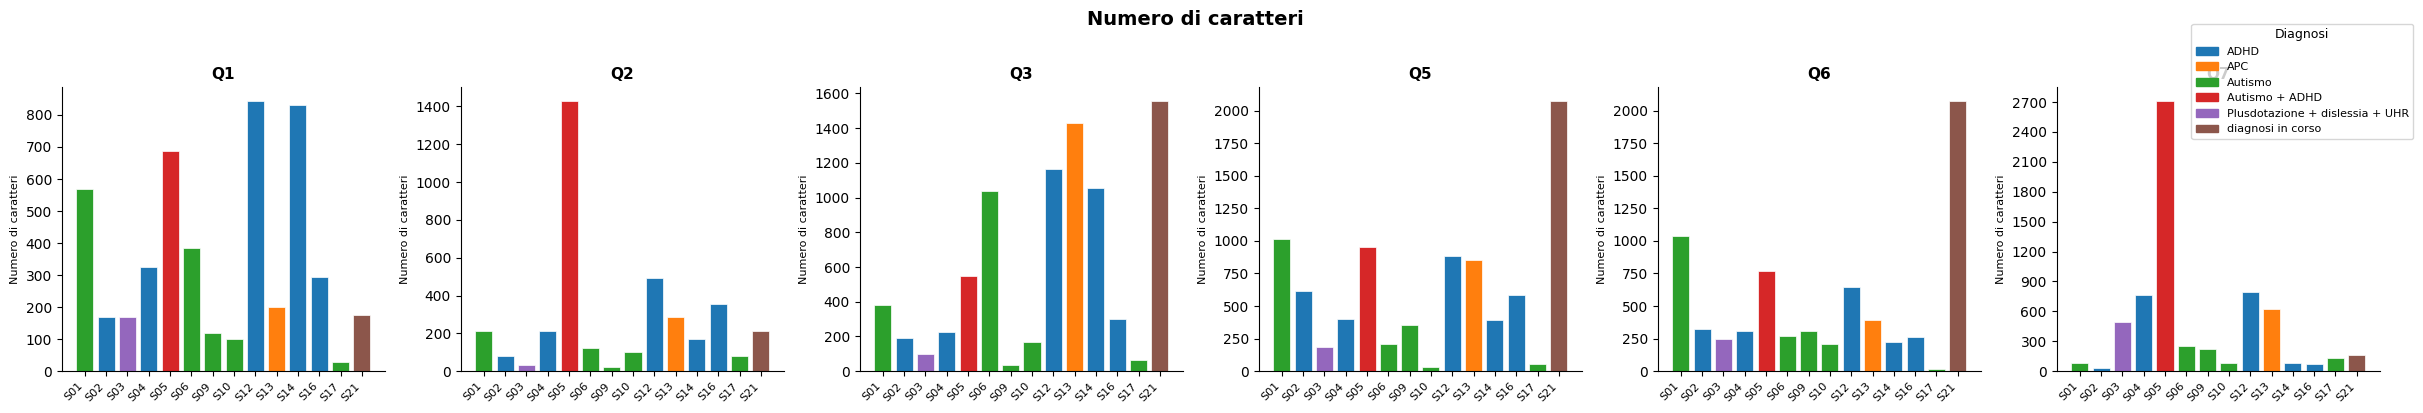

Salvato: istogramma_char.png


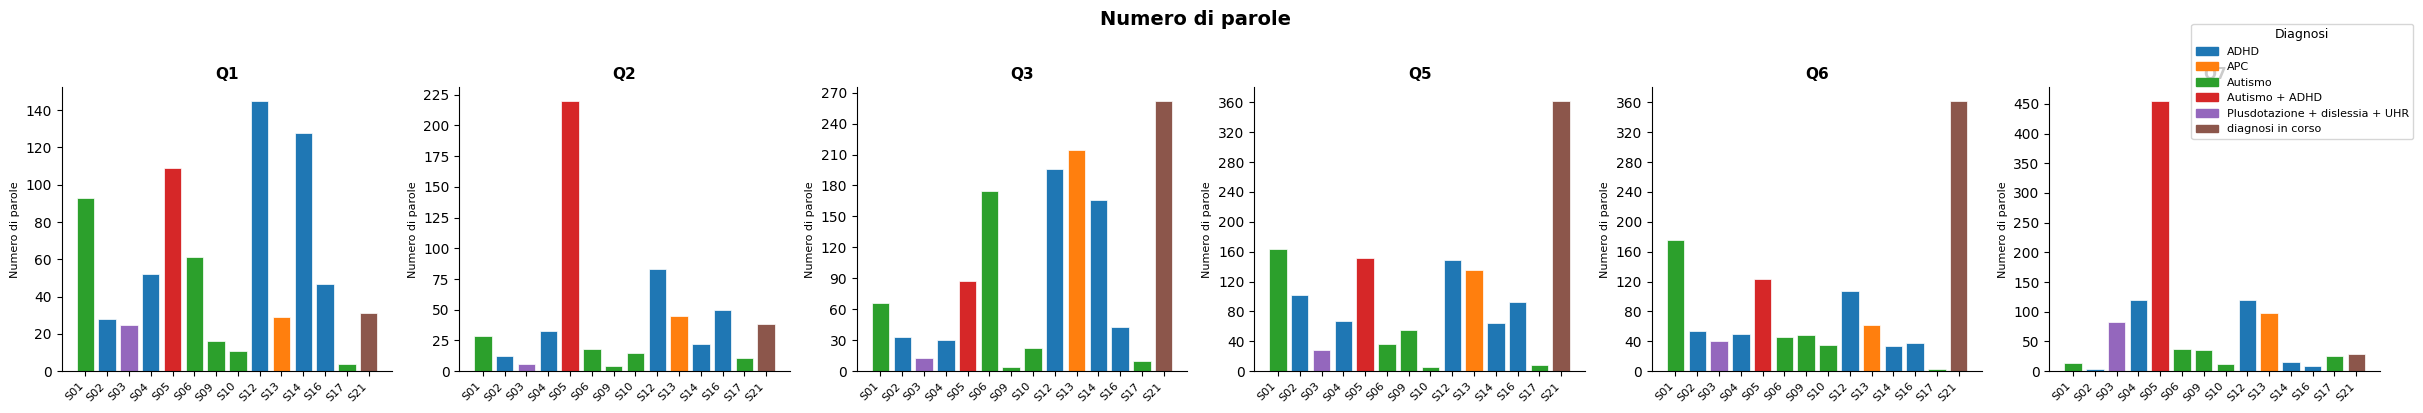

Salvato: istogramma_parole.png


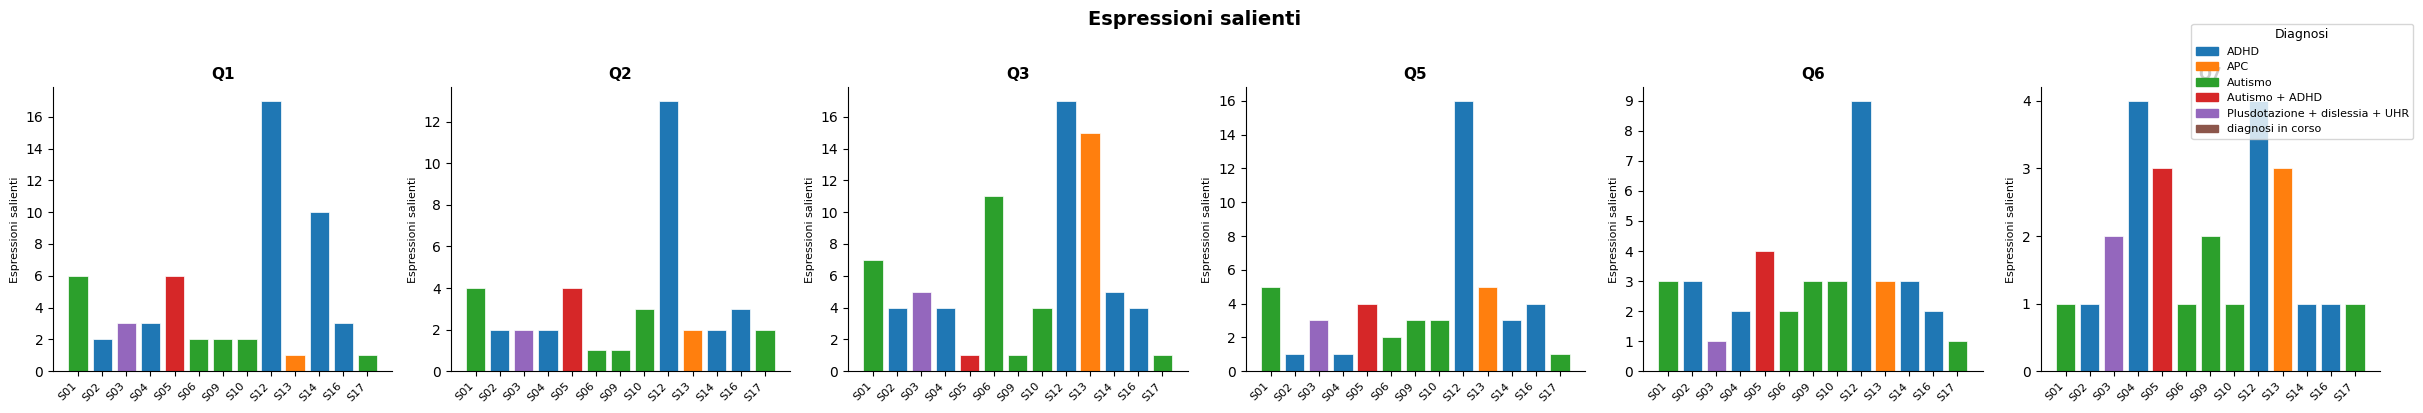

Salvato: istogramma_esp.png


In [41]:
# -----------------------------------------------------------------------
# Istogrammi: un grafico per conteggio (char / parole / esp) × domanda
# -----------------------------------------------------------------------
if df_conteggi.empty:
    print("Nessun dato disponibile per i grafici.")
else:
    # Ricaviamo le domande disponibili
    q_labels_plot = sorted(
        set(re.sub(r'_(char|parole|esp)$', '', c)
            for c in df_conteggi.columns if re.match(r'Q\d+_', c)),
        key=lambda x: int(re.sub(r'\D', '', x))
    )

    # Palette diagnosi
    diagnosi_uniche = df_conteggi["diagnosi"].unique()
    palette = plt.cm.tab10.colors
    color_map = {d: palette[i % len(palette)] for i, d in enumerate(sorted(diagnosi_uniche))}

    metriche = [
        ("char",   "Numero di caratteri"),
        ("parole", "Numero di parole"),
        ("esp",    "Espressioni salienti"),
    ]

    for suffix, titolo_metrica in metriche:
        fig, axes = plt.subplots(
            1, len(q_labels_plot),
            figsize=(4 * len(q_labels_plot), 4),
            sharey=False
        )
        # axes può essere un solo Axes se c'è una sola domanda
        if len(q_labels_plot) == 1:
            axes = [axes]

        fig.suptitle(titolo_metrica, fontsize=14, fontweight="bold", y=1.02)

        for ax, q in zip(axes, q_labels_plot):
            col = f"{q}_{suffix}"
            if col not in df_conteggi.columns:
                ax.set_visible(False)
                continue

            # Dati per questo grafico
            data = df_conteggi[[col, "diagnosi"]].dropna()
            soggetti = data.index.tolist()
            valori   = data[col].tolist()
            colori   = [color_map[d] for d in data["diagnosi"]]

            x = range(len(soggetti))
            ax.bar(x, valori, color=colori, edgecolor="white", linewidth=0.5)

            # Etichette asse X
            ax.set_xticks(list(x))
            ax.set_xticklabels(soggetti, rotation=45, ha="right", fontsize=8)
            ax.set_title(q, fontsize=11, fontweight="bold")
            ax.set_ylabel(titolo_metrica, fontsize=8)
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
            ax.spines[["top", "right"]].set_visible(False)

        # Legenda diagnosi (una sola per figura, in alto a destra)
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=color_map[d], label=d)
            for d in sorted(color_map)
        ]
        fig.legend(
            handles=handles,
            title="Diagnosi",
            loc="upper right",
            bbox_to_anchor=(1.01, 1.0),
            fontsize=8,
            title_fontsize=9
        )

        plt.tight_layout()
        plt.savefig(
            BASE_DIR / f"istogramma_{suffix}.png",
            dpi=150, bbox_inches="tight"
        )
        plt.show()
        print(f"Salvato: istogramma_{suffix}.png")


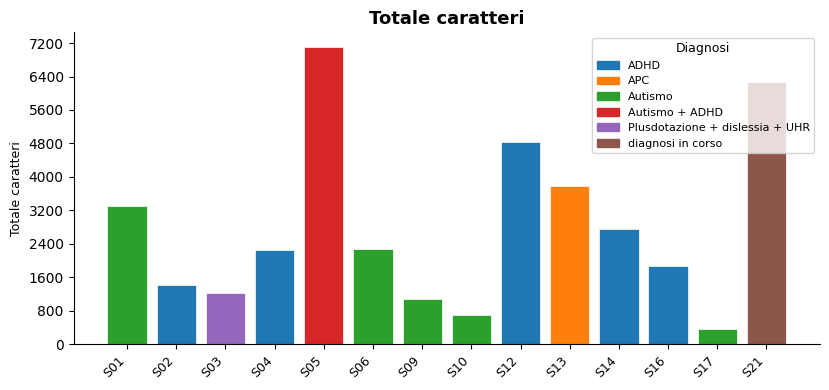

Salvato: istogramma_totale_char.png


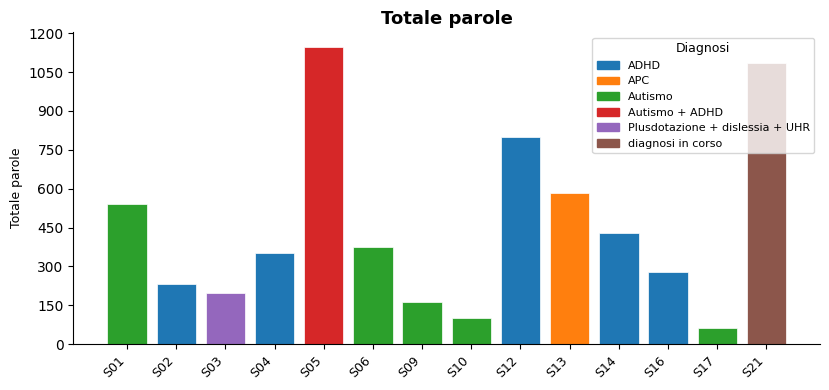

Salvato: istogramma_totale_parole.png


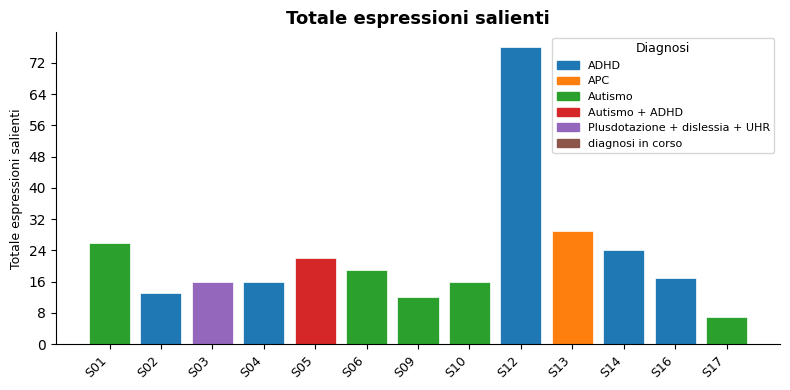

Salvato: istogramma_totale_esp.png


In [42]:
# -----------------------------------------------------------------------
# Istogrammi TOTALI: un grafico per ciascuna delle tre metriche
# Ogni grafico mostra un'unica barra per soggetto con il totale
# -----------------------------------------------------------------------
if not df_conteggi.empty:
    metriche_tot = [
        ("TOT_char",   "Totale caratteri"),
        ("TOT_parole", "Totale parole"),
        ("TOT_esp",    "Totale espressioni salienti"),
    ]

    for col, titolo in metriche_tot:
        if col not in df_conteggi.columns:
            print(f"Colonna '{col}' non trovata, skipping.")
            continue

        data = df_conteggi[[col, "diagnosi"]].dropna()
        soggetti = data.index.tolist()
        valori   = data[col].tolist()
        colori   = [color_map[d] for d in data["diagnosi"]]

        fig, ax = plt.subplots(figsize=(max(8, len(soggetti) * 0.6), 4))
        x = range(len(soggetti))
        ax.bar(x, valori, color=colori, edgecolor="white", linewidth=0.5)

        ax.set_xticks(list(x))
        ax.set_xticklabels(soggetti, rotation=45, ha="right", fontsize=9)
        ax.set_title(titolo, fontsize=13, fontweight="bold")
        ax.set_ylabel(titolo, fontsize=9)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.spines[["top", "right"]].set_visible(False)

        handles = [
            plt.Rectangle((0, 0), 1, 1, color=color_map[d], label=d)
            for d in sorted(color_map)
        ]
        ax.legend(handles=handles, title="Diagnosi", fontsize=8,
                  title_fontsize=9, loc="upper right")

        fname = col.lower().replace("tot_", "istogramma_totale_") + ".png"
        plt.tight_layout()
        plt.savefig(BASE_DIR / fname, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Salvato: {fname}")


## 10. Test statistici: ADHD vs tutti gli altri

Confrontiamo il gruppo **ADHD** contro il gruppo **non-ADHD** sui tre conteggi totali
(caratteri, parole, espressioni salienti).

**Logica di assegnazione al gruppo:**
- La diagnosi è ora una **lista** (es. `['Autismo', 'ADHD']`).
- Se la lista contiene `'ADHD'` (anche insieme ad altre diagnosi) → **ADHD**
- Tutti gli altri soggetti (Autismo, APC, DSA, Plusdotazione, diagnosi in corso…) → **non-ADHD**
- Nessun soggetto viene escluso: tutti partecipano al confronto.

**Procedura:**
1. **Shapiro-Wilk** per verificare la normalità (α = 0.05)
2. Se entrambi i gruppi sono normali → **t-test di Welch**; altrimenti → **Mann-Whitney U**
3. **Cohen's d** come misura dell'effect size

In [43]:
from scipy import stats
import numpy as np

# Livello di significatività usato in tutti i test
ALPHA = 0.05

# -----------------------------------------------------------------------
# 1. Assegnazione al gruppo
#
# diagnosi_map ora contiene liste (es. ['Autismo', 'ADHD']).
# In df_conteggi la colonna 'diagnosi' è già stata costruita a partire
# da quelle liste; il formato dipende da come è stato assemblato il
# DataFrame (lista Python oppure stringa unita con ' + ').
# Gestiamo entrambi i casi per robustezza.
# -----------------------------------------------------------------------

def gruppo(diagnosi) -> str:
    """
    Assegna il soggetto a uno dei due gruppi di confronto:
      - 'ADHD'     → se la diagnosi contiene 'ADHD' (anche in comorbidità)
      - 'non-ADHD' → tutti gli altri (Autismo, APC, DSA, diagnosi in corso…)

    Accetta sia una lista ['Autismo', 'ADHD'] sia una stringa 'Autismo + ADHD'.
    Il confronto è case-insensitive per sicurezza.
    """
    # Se la diagnosi è già una lista iteriamo direttamente sugli elementi
    if isinstance(diagnosi, list):
        # Controlliamo ogni etichetta della lista in minuscolo
        return "ADHD" if any("adhd" in str(d).lower() for d in diagnosi) else "non-ADHD"

    # Altrimenti trattiamo il valore come stringa (es. 'Autismo + ADHD')
    return "ADHD" if "adhd" in str(diagnosi).lower() else "non-ADHD"


# Lavoriamo su una copia di df_conteggi per non modificare il DataFrame originale
df_stat = df_conteggi.copy()

# Applichiamo la funzione di assegnazione a ogni riga
df_stat["gruppo"] = df_stat["diagnosi"].apply(gruppo)

# Creiamo i due sotto-DataFrame per i test successivi
df_adhd     = df_stat[df_stat["gruppo"] == "ADHD"]
df_non_adhd = df_stat[df_stat["gruppo"] == "non-ADHD"]

# Riepilogo a console: soggetti in ogni gruppo con diagnosi associata
print(f"Gruppo ADHD     (N={len(df_adhd)}): {list(zip(df_adhd.index, df_adhd['diagnosi']))}")
print(f"Gruppo non-ADHD (N={len(df_non_adhd)}): {list(zip(df_non_adhd.index, df_non_adhd['diagnosi']))}")
print(f"\nTotale soggetti nel confronto: {len(df_adhd) + len(df_non_adhd)}/{len(df_stat)}")


Gruppo ADHD     (N=6): [('S02', 'ADHD'), ('S04', 'ADHD'), ('S05', 'Autismo + ADHD'), ('S12', 'ADHD'), ('S14', 'ADHD'), ('S16', 'ADHD')]
Gruppo non-ADHD (N=8): [('S01', 'Autismo'), ('S03', 'Plusdotazione + dislessia + UHR'), ('S06', 'Autismo'), ('S09', 'Autismo'), ('S10', 'Autismo'), ('S13', 'APC'), ('S17', 'Autismo'), ('S21', 'diagnosi in corso')]

Totale soggetti nel confronto: 14/14


In [44]:
# -----------------------------------------------------------------------
# 2. Test statistici ADHD vs non-ADHD
#    Su ogni domanda (Qn_char, Qn_parole, Qn_esp) + totali (TOT_*)
#
# Per ogni colonna vengono eseguiti DUE test indipendenti:
#
#   TEST SULLA MEDIA:
#     - Shapiro-Wilk su entrambi i gruppi per verificare la normalità
#     - Se normali → t-test di Welch  (H0: medie uguali)
#     - Altrimenti → Mann-Whitney U   (H0: distribuzioni uguali per rango)
#
#   TEST SULLA MEDIANA:
#     - Test di Mood (scipy.stats.median_test)
#       H0: i due gruppi hanno la stessa mediana
#       Non richiede normalità; usa una grande mediana comune come soglia
#       e verifica con chi-quadro se i gruppi si distribuiscono
#       simmetricamente intorno ad essa.
#
#   EFFECT SIZE:
#     - Cohen's d (basato sulle medie) per entrambi i test
# -----------------------------------------------------------------------

import re as _re

# ── Etichette e ordinamento colonne ─────────────────────────────────────
_etichette = {
    "char":   "Caratteri",
    "parole": "Parole",
    "esp":    "Espressioni salienti",
}

def _sort_key(col):
    m = _re.match(r"(Q(\d+)|TOT)_(char|parole|esp)$", col)
    if not m:
        return (99, 999, col)
    is_tot   = 1 if m.group(1) == "TOT" else 0
    num      = int(m.group(2)) if m.group(2) else 0
    suffisso = {"char": 0, "parole": 1, "esp": 2}[m.group(3)]
    return (suffisso, is_tot, num)

def _label(col):
    m = _re.match(r"(Q\d+|TOT)_(char|parole|esp)$", col)
    if not m:
        return col
    domanda = "Totale" if m.group(1) == "TOT" else m.group(1)
    metrica = _etichette.get(m.group(2), m.group(2))
    return f"{domanda} — {metrica}"

cols_test = sorted(
    [c for c in df_stat.columns
     if _re.match(r"(Q\d+|TOT)_(char|parole|esp)$", c)],
    key=_sort_key
)

# ── Funzione principale di test ──────────────────────────────────────────
def esegui_test(a, b, label):
    """
    Esegue su due campioni a (ADHD) e b (non-ADHD):
      1. Shapiro-Wilk → t-Welch o Mann-Whitney U  (test sulla media)
      2. Test di Mood                              (test sulla mediana)
      3. Cohen's d                                 (effect size)

    Restituisce un dict con tutti i risultati, oppure None se i
    campioni sono troppo piccoli (< 3 per Shapiro-Wilk o < 2 per Mood).
    """
    if len(a) < 3 or len(b) < 3:
        return None

    # ── Shapiro-Wilk ────────────────────────────────────────────────────
    _, p_norm_a = stats.shapiro(a)
    _, p_norm_b = stats.shapiro(b)
    normale = (p_norm_a > ALPHA) and (p_norm_b > ALPHA)

    # ── Test sulla media ─────────────────────────────────────────────────
    if normale:
        stat_media, p_media = stats.ttest_ind(a, b, equal_var=False)
        test_media_nome = "t-Welch"
    else:
        stat_media, p_media = stats.mannwhitneyu(a, b, alternative="two-sided")
        test_media_nome = "Mann-Whitney U"

    # ── Test di Mood sulla mediana ───────────────────────────────────────
    # median_test restituisce: statistica chi2, p-value, grande mediana,
    # tabella di contingenza (quanti valori sopra/sotto la grande mediana)
    stat_mood, p_mood, gran_med, _ = stats.median_test(a, b)

    # ── Cohen's d ────────────────────────────────────────────────────────
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    cohens_d   = (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else np.nan
    d_mag      = ("piccolo" if abs(cohens_d) < 0.5
                  else "medio" if abs(cohens_d) < 0.8
                  else "grande")

    return {
        "colonna":            label,
        "n_ADHD":             len(a),
        "n_non_ADHD":         len(b),
        # descrittive
        "media_ADHD":         round(float(np.mean(a)),   1),
        "media_non_ADHD":     round(float(np.mean(b)),   1),
        "mediana_ADHD":       round(float(np.median(a)), 1),
        "mediana_non_ADHD":   round(float(np.median(b)), 1),
        # normalità
        "SW_ADHD_p":          round(p_norm_a, 3),
        "SW_nonADHD_p":       round(p_norm_b, 3),
        "normale":            normale,
        # test media
        "test_media":         test_media_nome,
        "stat_media":         round(stat_media, 3),
        "p_media":            round(p_media, 4),
        "sig_media":          "✅" if p_media < ALPHA else "❌",
        # test mediana (Mood)
        "test_mediana":       "Mood",
        "gran_mediana":       round(gran_med, 1),
        "stat_mood":          round(stat_mood, 3),
        "p_mediana":          round(p_mood, 4),
        "sig_mediana":        "✅" if p_mood < ALPHA else "❌",
        # effect size
        "Cohen_d":            round(cohens_d, 3) if not np.isnan(cohens_d) else np.nan,
        "effect_size":        d_mag,
    }

# ── Esecuzione ───────────────────────────────────────────────────────────
risultati  = []
sez_corrente = None

print("=" * 72)
print("TEST STATISTICI ADHD vs non-ADHD — per domanda e per metrica")
print("=" * 72)

for col in cols_test:
    m        = _re.match(r"(Q\d+|TOT)_(char|parole|esp)$", col)
    suffisso = m.group(2) if m else ""
    metrica  = _etichette.get(suffisso, suffisso)

    # Intestazione di sezione al cambio di metrica
    if metrica != sez_corrente:
        sez_corrente = metrica
        print(f"\n{'─' * 72}")
        print(f"  {metrica.upper()}")
        print(f"{'─' * 72}")

    if col not in df_stat.columns:
        continue

    a = df_adhd[col].dropna().values.astype(float)
    b = df_non_adhd[col].dropna().values.astype(float)

    res = esegui_test(a, b, _label(col))

    if res is None:
        print(f"  {_label(col)}: campioni troppo piccoli "
              f"(ADHD n={len(a)}, non-ADHD n={len(b)}) — test saltato")
        continue

    # Stampa per questa colonna
    print(f"\n  {res['colonna']}")
    print(f"    ADHD     → n={res['n_ADHD']},  "
          f"media={res['media_ADHD']},  mediana={res['mediana_ADHD']}")
    print(f"    non-ADHD → n={res['n_non_ADHD']},  "
          f"media={res['media_non_ADHD']},  mediana={res['mediana_non_ADHD']}")
    print(f"    Shapiro-Wilk: ADHD p={res['SW_ADHD_p']},  "
          f"non-ADHD p={res['SW_nonADHD_p']}  "
          f"→ {'normale' if res['normale'] else 'non normale'}")
    print(f"    [Media]   {res['test_media']}:  "
          f"stat={res['stat_media']},  p={res['p_media']}  {res['sig_media']}")
    print(f"    [Mediana] Test di Mood:  "
          f"gran mediana={res['gran_mediana']},  "
          f"χ²={res['stat_mood']},  p={res['p_mediana']}  {res['sig_mediana']}")
    print(f"    Cohen's d = {res['Cohen_d']}  ({res['effect_size']})")

    risultati.append(res)

# ── Tabella riepilogativa ────────────────────────────────────────────────
print(f"\n{'=' * 72}")
print("RIEPILOGO")
print(f"{'=' * 72}")
if risultati:
    df_risultati = pd.DataFrame(risultati).set_index("colonna")
    cols_riepilogo = [
        "n_ADHD", "n_non_ADHD",
        "media_ADHD", "media_non_ADHD",
        "mediana_ADHD", "mediana_non_ADHD",
        "test_media",   "p_media",   "sig_media",
        "test_mediana", "p_mediana", "sig_mediana",
        "Cohen_d", "effect_size",
    ]
    cols_riepilogo = [c for c in cols_riepilogo if c in df_risultati.columns]
    print(df_risultati[cols_riepilogo].to_string())


# ── Definizione metriche_test per il boxplot (cella successiva) ─────────
# Contiene solo le colonne TOT_* nell'ordine char → parole → esp
metriche_test = [
    (col, _label(col))
    for col in sorted(
        [c for c in df_stat.columns if c.startswith("TOT_")
         and _re.match(r"TOT_(char|parole|esp)$", c)],
        key=_sort_key
    )
]
print(f"\nmetriche_test definita: {metriche_test}")

TEST STATISTICI ADHD vs non-ADHD — per domanda e per metrica

────────────────────────────────────────────────────────────────────────
  CARATTERI
────────────────────────────────────────────────────────────────────────

  Q1 — Caratteri
    ADHD     → n=6,  media=525.5,  mediana=507.0
    non-ADHD → n=8,  media=218.2,  mediana=171.5
    Shapiro-Wilk: ADHD p=0.193,  non-ADHD p=0.132  → normale
    [Media]   t-Welch:  stat=2.253,  p=0.0561  ❌
    [Mediana] Test di Mood:  gran mediana=247.0,  χ²=2.625,  p=0.1052  ❌
    Cohen's d = 1.258  (grande)

  Q2 — Caratteri
    ADHD     → n=6,  media=456.0,  mediana=284.0
    non-ADHD → n=8,  media=134.5,  mediana=112.5
    Shapiro-Wilk: ADHD p=0.025,  non-ADHD p=0.506  → non normale
    [Media]   Mann-Whitney U:  stat=36.0,  p=0.1419  ❌
    [Mediana] Test di Mood:  gran mediana=191.0,  χ²=0.292,  p=0.5892  ❌
    Cohen's d = 0.896  (grande)

  Q3 — Caratteri
    ADHD     → n=6,  media=580.3,  mediana=424.5
    non-ADHD → n=8,  media=596.2,  median

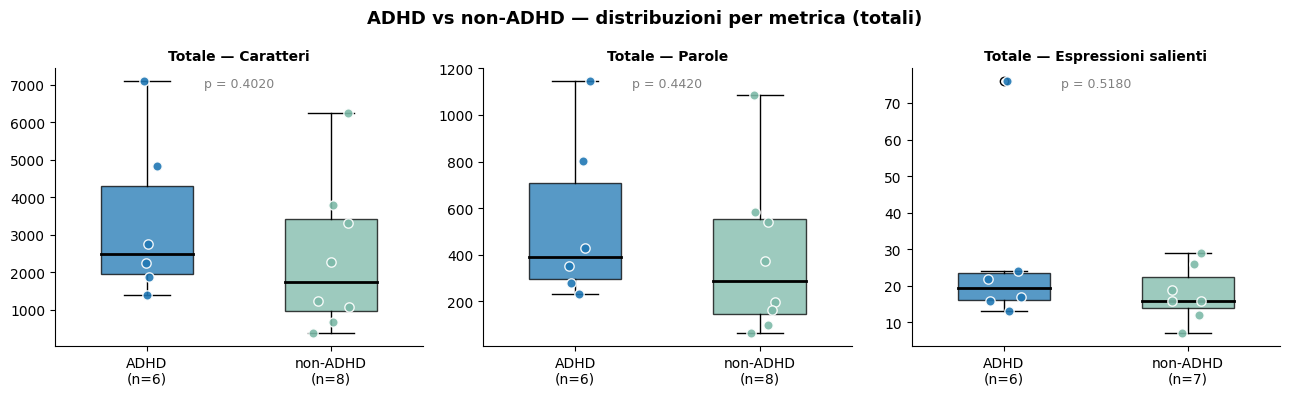

Salvato: boxplot_adhd_vs_non_adhd.png


In [45]:
# -----------------------------------------------------------------------
# 3. Boxplot ADHD vs non-ADHD con jitter e p-value annotato
#    Il boxplot mostra i tre totali (TOT_char, TOT_parole, TOT_esp).
#    Il p-value annotato è quello del test sulla media (t-Welch o Mann-Whitney U).
# -----------------------------------------------------------------------

# Procediamo solo se entrambi i gruppi hanno almeno un soggetto
if len(df_adhd) >= 1 and len(df_non_adhd) >= 1:

    # Costruiamo un dizionario di lookup col → p_media dai risultati dei test
    # così il boxplot non dipende dai nomi delle chiavi testuali
    lookup_p = {r["colonna"]: r["p_media"] for r in risultati}

    # metriche_test contiene le tre colonne totali con la loro etichetta leggibile
    # es. [("TOT_char", "Totale caratteri"), ("TOT_parole", ...), ("TOT_esp", ...)]
    # Costruiamo le label nel formato usato da _label() per il match con lookup_p
    import re as _re
    def _label_box(col):
        """Replica la funzione _label() della cella precedente per il lookup."""        
        m = _re.match(r"(Q\d+|TOT)_(char|parole|esp)$", col)
        if not m:
            return col
        domanda = "Totale" if m.group(1) == "TOT" else m.group(1)
        metrica = {"char": "Caratteri", "parole": "Parole", "esp": "Espressioni salienti"}.get(m.group(2), m.group(2))
        return f"{domanda} — {metrica}"

    # Una figura con tre pannelli affiancati, uno per metrica totale
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    fig.suptitle("ADHD vs non-ADHD — distribuzioni per metrica (totali)",
                 fontsize=13, fontweight="bold")

    # Colori fissi per i due gruppi
    colori_box = {
        "ADHD":     color_map.get("ADHD",    "#DD8452"),
        "non-ADHD": "#7CB9A8",
    }

    for ax, (col, label) in zip(axes, metriche_test):

        # Nascondiamo il pannello se la colonna non esiste
        if col not in df_stat.columns:
            ax.set_visible(False)
            continue

        # Valori puliti per ciascun gruppo
        dati_adhd     = df_adhd[col].dropna().values
        dati_non_adhd = df_non_adhd[col].dropna().values
        dati = [dati_adhd, dati_non_adhd]

        # Boxplot
        bp = ax.boxplot(dati, patch_artist=True,
                        medianprops=dict(color="black", linewidth=2),
                        widths=0.5)
        for patch, grp in zip(bp["boxes"], ["ADHD", "non-ADHD"]):
            patch.set_facecolor(colori_box[grp])
            patch.set_alpha(0.75)

        # Jitter dei punti individuali
        for i, (grp_data, grp) in enumerate(zip(dati, ["ADHD", "non-ADHD"]), start=1):
            jitter = np.random.uniform(-0.1, 0.1, size=len(grp_data))
            ax.scatter(i + jitter, grp_data,
                       color=colori_box[grp], edgecolor="white",
                       s=45, zorder=3, alpha=0.9)

        # Etichette asse x
        ax.set_xticks([1, 2])
        ax.set_xticklabels(
            [f"ADHD\n(n={len(dati_adhd)})", f"non-ADHD\n(n={len(dati_non_adhd)})"],
            fontsize=10
        )
        ax.set_title(label, fontsize=10, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)

        # Recuperiamo il p-value del test sulla media tramite lookup sul nome colonna
        chiave = _label_box(col)
        p = lookup_p.get(chiave)
        if p is not None:
            p_str = f"p = {p:.4f}" + ("  *" if p < ALPHA else "")
            ax.text(0.5, 0.97, p_str, transform=ax.transAxes,
                    ha="center", va="top", fontsize=9,
                    color="darkred" if p < ALPHA else "gray")

    plt.tight_layout()
    plt.savefig(BASE_DIR / "boxplot_adhd_vs_non_adhd.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvato: boxplot_adhd_vs_non_adhd.png")


## 11. Export PDF — risultati test statistici

Genera un PDF con:
- intestazione con parametri dell'analisi (N soggetti, α, gruppi)
- tabella riepilogativa di tutti i test (una riga per metrica)
- sezione dettaglio per ogni metrica con descrittive, test, effect size
- boxplot allegato in fondo


In [46]:
# ══════════════════════════════════════════════════════════════════════════════
# SEZIONE 11 — Export PDF risultati test statistici
# Dipende da: risultati, df_risultati, df_adhd, df_non_adhd, ALPHA, BASE_DIR
# ══════════════════════════════════════════════════════════════════════════════

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.units import cm
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.enums import TA_LEFT, TA_CENTER
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, HRFlowable,
    Table, TableStyle, Image, PageBreak
)
from reportlab.platypus import KeepTogether
import datetime

OUTPUT_PDF = BASE_DIR / "test_statistici_ADHD_vs_nonADHD.pdf"

# ── Stili tipografici ─────────────────────────────────────────────────────────
stili = getSampleStyleSheet()

S_TITOLO = ParagraphStyle("titolo",
    parent=stili["Heading1"], fontSize=15, spaceAfter=4,
    textColor=colors.HexColor("#1a2e4a"))
S_SOTTOTITOLO = ParagraphStyle("sottotitolo",
    parent=stili["Normal"], fontSize=9, spaceAfter=2,
    textColor=colors.HexColor("#555555"))
S_SEZ = ParagraphStyle("sezione",
    parent=stili["Heading2"], fontSize=11, spaceBefore=12, spaceAfter=4,
    textColor=colors.HexColor("#2c3e50"))
S_METRICA = ParagraphStyle("metrica",
    parent=stili["Heading3"], fontSize=10, spaceBefore=8, spaceAfter=3,
    textColor=colors.HexColor("#34495e"))
S_BODY = ParagraphStyle("body",
    parent=stili["Normal"], fontSize=8.5, spaceAfter=2, leading=13)
S_NOTE = ParagraphStyle("note",
    parent=stili["Normal"], fontSize=7.5, spaceAfter=2,
    textColor=colors.HexColor("#777777"), leading=11)

# ── Colori tabelle ────────────────────────────────────────────────────────────
C_HEADER   = colors.HexColor("#2c3e50")
C_ROW_A    = colors.HexColor("#f2f3f4")
C_ROW_B    = colors.white
C_SIG      = colors.HexColor("#fdecea")   # sfondo riga significativa
C_SIG_TXT  = colors.HexColor("#c0392b")

STYLE_TAB_BASE = [
    ("BACKGROUND",    (0, 0), (-1, 0),  C_HEADER),
    ("TEXTCOLOR",     (0, 0), (-1, 0),  colors.white),
    ("FONTNAME",      (0, 0), (-1, 0),  "Helvetica-Bold"),
    ("FONTSIZE",      (0, 0), (-1, -1), 7.5),
    ("ALIGN",         (1, 0), (-1, -1), "CENTER"),
    ("ALIGN",         (0, 0), (0, -1),  "LEFT"),
    ("VALIGN",        (0, 0), (-1, -1), "MIDDLE"),
    ("TOPPADDING",    (0, 0), (-1, -1), 3),
    ("BOTTOMPADDING", (0, 0), (-1, -1), 3),
    ("LEFTPADDING",   (0, 0), (-1, -1), 5),
    ("GRID",          (0, 0), (-1, -1), 0.4, colors.HexColor("#cccccc")),
]

def stile_righe_alternato(n_righe, sig_rows=None):
    """Restituisce comandi TableStyle per righe alternate + evidenziazione significative."""
    cmds = []
    for i in range(1, n_righe + 1):
        bg = C_ROW_A if i % 2 == 0 else C_ROW_B
        cmds.append(("BACKGROUND", (0, i), (-1, i), bg))
    if sig_rows:
        for i in sig_rows:
            cmds.append(("BACKGROUND", (0, i), (-1, i), C_SIG))
    return cmds


# ── Costruzione del documento ─────────────────────────────────────────────────
doc = SimpleDocTemplate(
    str(OUTPUT_PDF),
    pagesize=A4,
    leftMargin=2*cm, rightMargin=2*cm,
    topMargin=2*cm, bottomMargin=2*cm
)

elementi = []
W = 17 * cm   # larghezza utile

# ── Intestazione ──────────────────────────────────────────────────────────────
oggi = datetime.date.today().strftime("%d/%m/%Y")
elementi.append(Paragraph("Test statistici — ADHD vs non-ADHD", S_TITOLO))
elementi.append(Paragraph(
    f"Analisi PRE_CONS · {len(df_adhd) + len(df_non_adhd)} soggetti · "
    f"ADHD n={len(df_adhd)} · non-ADHD n={len(df_non_adhd)} · "
    f"α={ALPHA} · generato il {oggi}",
    S_SOTTOTITOLO))
elementi.append(HRFlowable(width=W, thickness=1.5,
                             color=colors.HexColor("#2c3e50"), spaceAfter=10))

# ── Note metodologiche ────────────────────────────────────────────────────────
elementi.append(Paragraph("Metodologia", S_SEZ))
elementi.append(Paragraph(
    "Per ogni metrica (caratteri, parole, espressioni salienti) su ogni domanda e sui totali "
    "sono stati eseguiti due test indipendenti:", S_BODY))
elementi.append(Paragraph(
    "<b>Test sulla media</b>: Shapiro-Wilk per verificare la normalità in entrambi i gruppi. "
    "Se entrambi normali → t-test di Welch; altrimenti → Mann-Whitney U (two-sided).", S_BODY))
elementi.append(Paragraph(
    "<b>Test sulla mediana</b>: Test di Mood (χ²). Non richiede normalità; "
    "verifica se i due gruppi si distribuiscono simmetricamente attorno alla grande mediana comune.", S_BODY))
elementi.append(Paragraph(
    "<b>Effect size</b>: Cohen's d (piccolo |d|<0.5, medio 0.5≤|d|<0.8, grande |d|≥0.8). "
    f"Righe con sfondo rosso = p-value < α ({ALPHA}).", S_BODY))
elementi.append(Spacer(1, 0.4*cm))

# ── Tabella riepilogativa ─────────────────────────────────────────────────────
elementi.append(Paragraph("Riepilogo risultati", S_SEZ))

intestazione_riep = [
    "Metrica",
    "Media\nADHD", "Media\nnon-ADHD",
    "Med.\nADHD",  "Med.\nnon-ADHD",
    "Test\nmedia",  "p\nmedia",  "Sig.",
    "p\nMood",      "Sig.",
    "Cohen d",      "Magn.",
]

righe_riep = [intestazione_riep]
sig_rows_riep = []

for i, r in enumerate(risultati, start=1):
    sig = r["p_media"] < ALPHA or r["p_mediana"] < ALPHA
    if sig:
        sig_rows_riep.append(i)
    righe_riep.append([
        r["colonna"],
        str(r["media_ADHD"]),      str(r["media_non_ADHD"]),
        str(r["mediana_ADHD"]),    str(r["mediana_non_ADHD"]),
        r["test_media"],           str(r["p_media"]),  r["sig_media"],
        str(r["p_mediana"]),       r["sig_mediana"],
        str(r["Cohen_d"]),         r["effect_size"],
    ])

col_w_riep = [
    4.5*cm,
    1.3*cm, 1.5*cm,
    1.2*cm, 1.4*cm,
    2.0*cm, 1.3*cm, 0.8*cm,
    1.3*cm, 0.8*cm,
    1.3*cm, 1.2*cm,
]

tab_riep = Table(righe_riep, colWidths=col_w_riep, repeatRows=1)
tab_riep.setStyle(TableStyle(
    STYLE_TAB_BASE + stile_righe_alternato(len(risultati), sig_rows_riep)
))
elementi.append(tab_riep)
elementi.append(Spacer(1, 0.3*cm))
elementi.append(Paragraph(
    "Sfondo rosso = almeno un test risulta significativo (p < α). "
    "✅ = significativo · ❌ = non significativo.",
    S_NOTE))

# ── Dettaglio per metrica ─────────────────────────────────────────────────────
elementi.append(PageBreak())
elementi.append(Paragraph("Dettaglio per metrica", S_SEZ))

for r in risultati:
    sig_media   = r["p_media"]   < ALPHA
    sig_mediana = r["p_mediana"] < ALPHA

    # Titolo metrica con badge significatività
    badge = " <font color='#c0392b'><b>[*]</b></font>" if (sig_media or sig_mediana) else ""
    blocco = [
        Paragraph(r["colonna"] + badge, S_METRICA),
    ]

    # Tabella descrittive
    desc_rows = [
        ["Gruppo", "N", "Media", "Mediana"],
        ["ADHD",     r["n_ADHD"],     r["media_ADHD"],     r["mediana_ADHD"]],
        ["non-ADHD", r["n_non_ADHD"], r["media_non_ADHD"], r["mediana_non_ADHD"]],
    ]
    tab_desc = Table(desc_rows, colWidths=[3*cm, 1.5*cm, 2.5*cm, 2.5*cm])
    tab_desc.setStyle(TableStyle(
        STYLE_TAB_BASE + stile_righe_alternato(2)
    ))
    blocco.append(tab_desc)
    blocco.append(Spacer(1, 0.15*cm))

    # Normalità
    norm_str = ("normale" if r["normale"] else "non normale")
    blocco.append(Paragraph(
        f"Shapiro-Wilk: ADHD p={r['SW_ADHD_p']} · non-ADHD p={r['SW_nonADHD_p']} "
        f"→ distribuzione <b>{norm_str}</b>", S_BODY))

    # Test media
    p_col_media = C_SIG_TXT if sig_media else colors.HexColor("#555555")
    blocco.append(Paragraph(
        f"<b>Test media ({r['test_media']})</b>: "
        f"stat={r['stat_media']} · "
        f"<font color='{'#c0392b' if sig_media else '#555555'}'>"
        f"p={r['p_media']} {r['sig_media']}</font>",
        S_BODY))

    # Test mediana
    blocco.append(Paragraph(
        f"<b>Test mediana (Mood χ²)</b>: "
        f"gran mediana={r['gran_mediana']} · stat={r['stat_mood']} · "
        f"<font color='{'#c0392b' if sig_mediana else '#555555'}'>"
        f"p={r['p_mediana']} {r['sig_mediana']}</font>",
        S_BODY))

    # Effect size
    blocco.append(Paragraph(
        f"Cohen's d = <b>{r['Cohen_d']}</b> ({r['effect_size']})",
        S_BODY))

    blocco.append(HRFlowable(width=W, thickness=0.4,
                              color=colors.HexColor("#cccccc"), spaceAfter=4))

    elementi.append(KeepTogether(blocco))

# ── Boxplot allegato ──────────────────────────────────────────────────────────
boxplot_path = BASE_DIR / "boxplot_adhd_vs_non_adhd.png"
if boxplot_path.exists():
    elementi.append(PageBreak())
    elementi.append(Paragraph("Boxplot — distribuzioni per metrica (totali)", S_SEZ))
    elementi.append(Paragraph(
        "I punti sovrapposti (jitter) rappresentano i singoli soggetti. "
        "Il p-value annotato è quello del test sulla media (t-Welch o Mann-Whitney U).",
        S_NOTE))
    elementi.append(Spacer(1, 0.3*cm))
    elementi.append(Image(str(boxplot_path), width=W, height=W * 0.38))
else:
    elementi.append(Paragraph(
        "(boxplot non disponibile — eseguire prima la cella 24)", S_NOTE))

# ── Build ─────────────────────────────────────────────────────────────────────
doc.build(elementi)
print(f"✅ PDF salvato: {OUTPUT_PDF.resolve()}")


✅ PDF salvato: C:\Users\giugg\OneDrive\Desktop\brondino\DIAGNOSI\test_statistici_ADHD_vs_nonADHD.pdf
